# Task 2 - Step 0: Prepare PACS and the shared source splits

* Downloads PACS (Hugging Face mirror `flwrlabs/pacs`, one parquet file, SHA-256 checked), decodes every
  image, resizes it to **256x256** and caches uint8 tensors per domain in `data/pacs/` (git-ignored).
* Checks the per-domain image counts against the PACS paper (Photo 1670, Art 2048, Cartoon 2344, Sketch 3929).
* Creates the **stratified 80/20 train/validation split within each source domain** (seed 6304) and saves it to
  `shared/splits/pacs_sketch_seed6304.json`. Tasks 2 and 3 both reuse this file.

**Sketch labels are never loaded here.** They are written to a separate file that only
`shared.pacs.load_target_labels()` can return, and that function refuses to run until a freeze manifest exists
(written by notebook 02 after every checkpoint and prediction is fixed). For the same reason this notebook
reports only the *total* Sketch image count, not its class distribution.

In [1]:
# ---- Task 2 common header (identical in every Task 2 notebook) ----
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Locate the repository root (the folder containing shared/) and make it importable.
REPO = Path.cwd().resolve()
while not (REPO / "shared" / "pacs.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared import pacs, pacs_protocol as proto
from shared.config import load_config

T2 = REPO / "task2"
CFG_DIR = T2 / "configs"
SEED = 6304
# Smoke mode (env TASK2_SMOKE=1): 2 epochs x 5 updates per run, all outputs under _smoke/ folders,
# and notebook 03 uses RANDOM labels instead of loading the real Sketch labels.
SMOKE = os.environ.get("TASK2_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T2 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T2 / "results" / "tables"      # data-preparation tables (same in smoke and real mode)
CKPT = T2 / "checkpoints" / SUB            # git-ignored
CACHE = T2 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Config names (files in task2/configs). The main comparison uses lambda = 1 for DAN.
# DANN/CDAN with the manual's exact settings were unstable (DANN diverged, CDAN collapsed repeatedly). Two fixes
# were tried, both chosen from source-side evidence only (see task2/RUN_LOG.md):
#   1) discriminator lr x10 (2026-09-22, before target evaluation): CDAN stable, DANN diverged at epoch 10;
#   2) BatchNorm in the discriminator hidden layer, manual lr (post-evaluation rerun after root-cause diagnosis).
# Fix 2 passes the pre-set stability criteria for both and is the main DANN/CDAN row; all other runs are reported.
MAIN_RUNS = ["source_only", "dan", "dann_discbn", "cdan_discbn"]
ADAPT_MAIN = ["dan", "dann_discbn", "cdan_discbn"]
AS_SPECIFIED_ADV = ["dann", "cdan"]
DISCLR10_ADV = ["dann_disclr10", "cdan_disclr10"]
ADV_RUNS = ["dann_discbn", "cdan_discbn", "dann_disclr10", "cdan_disclr10", "dann", "cdan"]
STUDY_RUNS = ["dan_lambda0.1", "dan", "dan_lambda10"]          # DAN lambda in {0.1, 1, 10}
ALL_RUNS = MAIN_RUNS + DISCLR10_ADV + AS_SPECIFIED_ADV + ["dan_lambda0.1", "dan_lambda10"]
RUN_NAME = {c: load_config(CFG_DIR, c)["run_name"] for c in ALL_RUNS}
LABEL = {"source_only": "Source-only", "dan": "DAN (λ=1)", "dann_discbn": "DANN (disc BN)", "cdan_discbn": "CDAN (disc BN)",
         "dann_disclr10": "DANN (disc lr×10)",
         "cdan_disclr10": "CDAN (disc lr×10)", "dann": "DANN (as specified)", "cdan": "CDAN (as specified)",
         "dan_lambda0.1": "DAN (λ=0.1)", "dan_lambda10": "DAN (λ=10)"}

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    """Every figure is saved as PNG + PDF (never only displayed)."""
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
summary = pacs.prepare_pacs()
CLASSES = summary["classes"]
print("classes:", CLASSES)
print("images per domain:", summary["counts"])
pd.DataFrame(summary["source_class_counts"])

classes: ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
images per domain: {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929}


,photo,art_painting,cartoon
dog,189,379,389
elephant,202,255,457
giraffe,182,285,346
guitar,186,184,135
horse,199,201,324
house,280,295,288
person,432,449,405


## Stratified 80/20 split per source domain (seed 6304)

In [3]:
splits = proto.make_source_splits()
rows = []
for dom in pacs.SOURCE_DOMAINS:
    _, y = pacs.load_source_domain(dom)
    y = y.numpy()
    tr, va = np.asarray(splits["domains"][dom]["train_idx"]), np.asarray(splits["domains"][dom]["val_idx"])
    assert len(np.intersect1d(tr, va)) == 0 and len(tr) + len(va) == len(y)
    for part, idx in [("train", tr), ("val", va)]:
        rows.append({"domain": dom, "part": part, "n": len(idx), **{c: int((y[idx] == k).sum()) for k, c in enumerate(CLASSES)}})
SPLIT_TABLE = pd.DataFrame(rows)
train_sizes = {d: splits["domains"][d]["n_train"] for d in pacs.SOURCE_DOMAINS}
IPE = proto.iters_per_epoch(train_sizes, load_config(CFG_DIR, "source_only")["train"]["n_per_source"])
print("updates per epoch = ceil(largest source-train domain / 8) =", IPE)
SPLIT_TABLE

updates per epoch = ceil(largest source-train domain / 8) = 235


,domain,part,n,dog,elephant,giraffe,guitar,horse,house,person
0,photo,train,1336,151,161,146,149,159,224,346
1,photo,val,334,38,41,36,37,40,56,86
2,art_painting,train,1638,303,204,228,147,161,236,359
3,art_painting,val,410,76,51,57,37,40,59,90
4,cartoon,train,1875,311,366,277,108,259,230,324
5,cartoon,val,469,78,91,69,27,65,58,81


In [4]:
data_summary = {"parquet_sha256": summary["parquet_sha256"], "classes": CLASSES, "images_per_domain": summary["counts"],
                "source_class_counts": summary["source_class_counts"], "split_file": "shared/splits/pacs_sketch_seed6304.json",
                "split_seed": splits["seed"], "split_sizes": {d: {"train": splits["domains"][d]["n_train"], "val": splits["domains"][d]["n_val"]}
                                                          for d in pacs.SOURCE_DOMAINS},
                "target_images": summary["counts"]["sketch"], "updates_per_epoch": IPE}
(DATA_TAB / "task2_data_summary.json").write_text(json.dumps(data_summary, indent=1))
SPLIT_TABLE.to_csv(DATA_TAB / "task2_split_class_counts.csv", index=False)
print(json.dumps(data_summary["split_sizes"], indent=1))

{
 "photo": {
  "train": 1336,
  "val": 334
 },
 "art_painting": {
  "train": 1638,
  "val": 410
 },
 "cartoon": {
  "train": 1875,
  "val": 469
 }
}


## Example images (source: one per class; Sketch: random, **unlabelled**)

saved figure task2_example_images


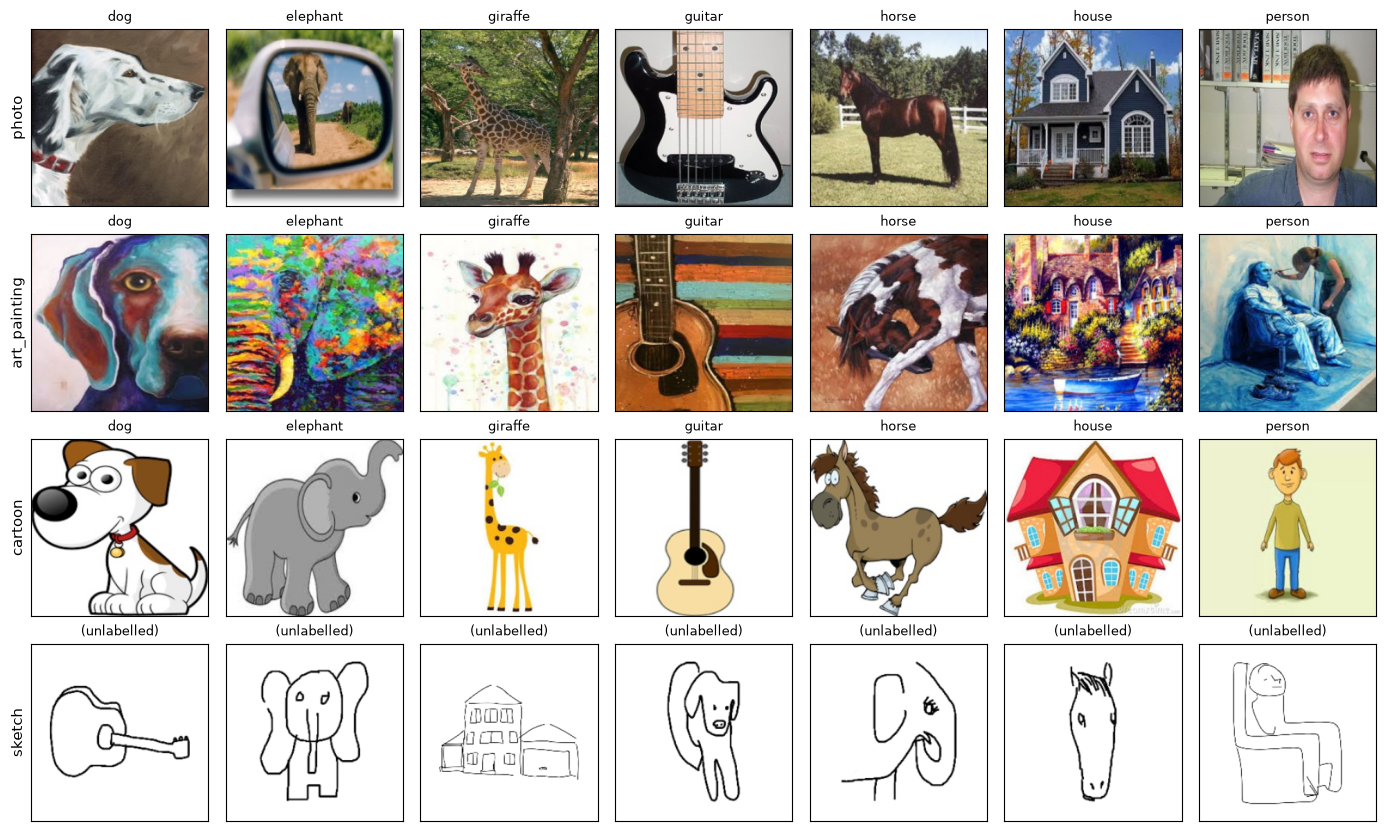

In [5]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(4, 7, figsize=(14, 8.4))
for r, dom in enumerate(pacs.DOMAINS):
    if dom == pacs.TARGET_DOMAIN:
        x = pacs.load_target_images()
        picks, titles = rng.choice(len(x), 7, replace=False), ["(unlabelled)"] * 7
    else:
        x, y = pacs.load_source_domain(dom)
        picks = [int(np.flatnonzero(y.numpy() == k)[0]) for k in range(7)]
        titles = CLASSES
    for c, (i, t) in enumerate(zip(picks, titles)):
        axes[r, c].imshow(x[i].permute(1, 2, 0).numpy()); axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        axes[r, c].set_title(t, fontsize=9)
    axes[r, 0].set_ylabel(dom, fontsize=11)
plt.tight_layout(); savefig(fig, "task2_example_images"); plt.show()